# INFY Stock Data Analysis

## IMPORTING LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## DATA COLLECTION

In [5]:
df = yf.download("INFY.NS", start="2018-01-01", end="2026-01-01")

# Fix multi-level columns
df.columns = df.columns.droplevel(1)
df.columns.name = None
df.reset_index(inplace=True)
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2018-01-01,415.244263,419.643570,413.817977,416.911548,5431340
1,2018-01-02,413.697418,418.639148,411.005612,416.730764,6112248
2,2018-01-03,410.322571,414.460745,409.237800,413.215284,6846552
3,2018-01-04,407.952118,410.201992,405.621862,410.201992,8947614
4,2018-01-05,406.586090,412.371515,404.175501,407.911909,11025976


## SAVING THE DATASET

In [45]:
df.to_csv("infy_stock_data.csv", index=False)
print("CSV file saved successfully!")

CSV file saved successfully!


## DATA UNDERSTANDING

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1976 non-null   datetime64[ns]
 1   Close   1976 non-null   float64       
 2   High    1976 non-null   float64       
 3   Low     1976 non-null   float64       
 4   Open    1976 non-null   float64       
 5   Volume  1976 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 92.8 KB


,Date,Close,High,Low,Open,Volume
count,1976,1976.000000,1976.000000,1976.000000,1976.000000,1.976000e+03
mean,2022-01-02 02:03:53.198380288,1152.949853,1164.268134,1141.589644,1153.021230,7.903865e+06
min,2018-01-01 00:00:00,406.586090,410.201992,404.175501,407.911909,0.000000e+00
25%,2020-01-07 18:00:00,635.255875,640.766669,628.677739,635.056813,4.969856e+06
50%,2022-01-01 12:00:00,1305.915955,1318.679108,1293.389648,1306.477172,6.711880e+06
75%,2024-01-01 06:00:00,1502.222321,1513.961785,1486.898311,1497.580513,8.948911e+06
max,2025-12-31 00:00:00,1942.221191,1948.777171,1920.756459,1938.093361,9.043211e+07
std,NaN,437.729756,441.181042,434.128911,437.894516,5.409529e+06


## CREATING TARGET VARIABLE

In [7]:
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

##  FEATURE ENGINEERING

In [13]:
df['MA10'] = df['Close'].rolling(10).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(10).std()

## CLEANING DATA

In [37]:
df = df.dropna(subset=['MA10','MA50','Return','Volatility','Target'])

## EXPLORATORY DATA ANALYSIS (EDA)

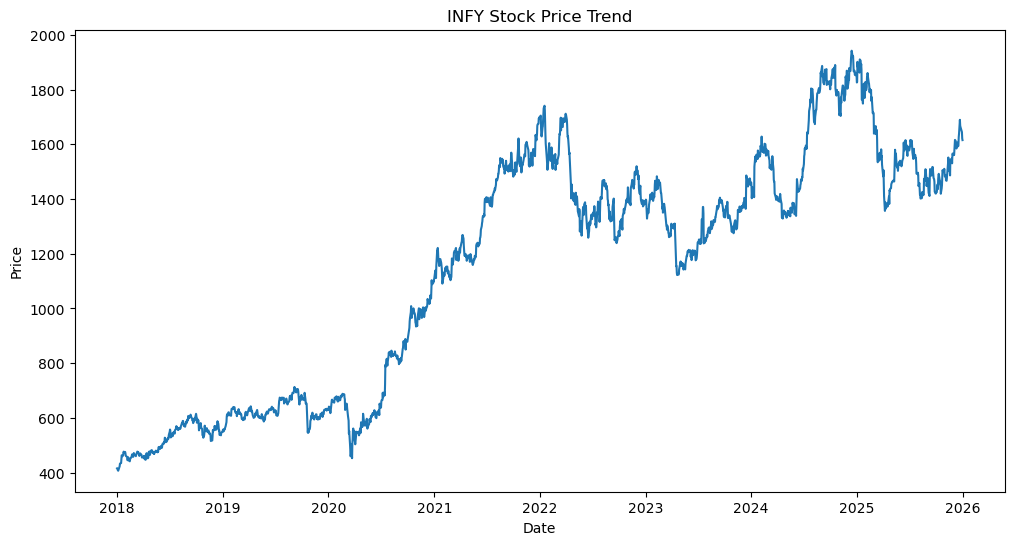

In [10]:
 1. Trend Analysis
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("INFY Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

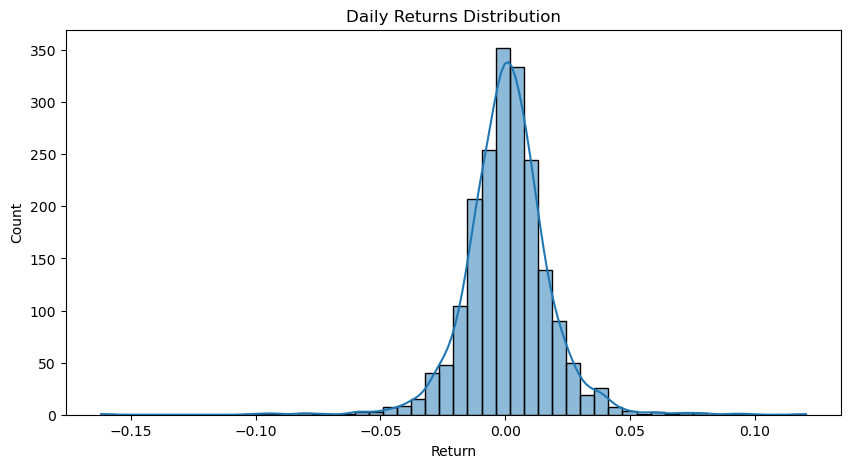

In [14]:
# 2. Daily Returns Distribution

plt.figure(figsize=(10,5))
sns.histplot(df['Return'], bins=50, kde=True)
plt.title("Daily Returns Distribution")
plt.show()

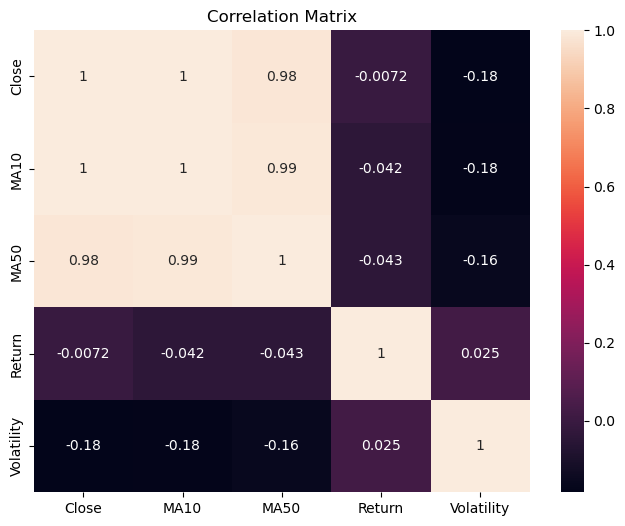

In [15]:
# 3. Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df[['Close','MA10','MA50','Return','Volatility']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Correlation with Target (in percentage)

In [20]:
target_corr = corr_matrix['Target'].drop('Target') * 100
print("\nCorrelation with Target (%):\n")
print(target_corr.sort_values(ascending=False))


Correlation with Target (%):

Volatility    4.120979
MA50         -4.380329
MA10         -4.515529
Return       -4.747713
Close        -4.796974
Name: Target, dtype: float64


## MODEL PREPARATION

In [38]:
X = data[['MA10', 'MA50', 'Return', 'Volatility']]
y = data['Target']

## Train-Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

## MODEL TRAINING

In [41]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## PREDICTION & EVALUATION

In [42]:
pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))



Accuracy: 0.533678756476684

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.04      0.08       186
           1       0.53      0.99      0.69       200

    accuracy                           0.53       386
   macro avg       0.66      0.52      0.38       386
weighted avg       0.66      0.53      0.40       386



## CONFUSION MATRIX

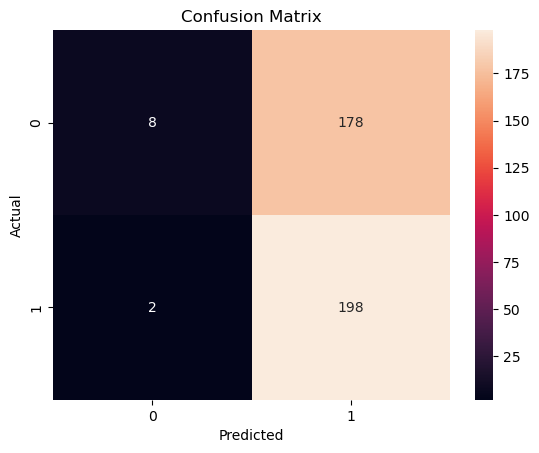

In [43]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##  Conclusion

This project analyzed Infosys (INFY.NS) stock data and built a model to predict next-day price direction (UP/DOWN).
The results show that basic technical indicators provide limited predictive power, with model accuracy close to random guessing.

##  Key Insights

* Moving averages follow price trends but do not strongly predict direction.
* Returns and volatility show weak correlation with the target variable.
* Stock movements are highly unpredictable using simple features alone.
* More advanced features and models are required for better performance.
